In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model
from scipy.stats import chi2
import math as math
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
from functions import coordinate_swap



ImportError: cannot import name 'coordinate_swap' from 'functions' (c:\Users\manou\OneDrive\Documenten\GitHub\paperstack\Manou_version\code\functions.py)

In [22]:
# tweak these
N_points = 60
leniency = 5
y_err = 1

# maybe tweak these for better results
sigma = 2

COR = []
COR_err = []

coordinate_swap(1)

NameError: name 'coordinate_swap' is not defined

laagtepunt bevindt zich op 96 frames.
laagtepunt bevindt zich op 253 frames.
Meting op dikte V_d0_1


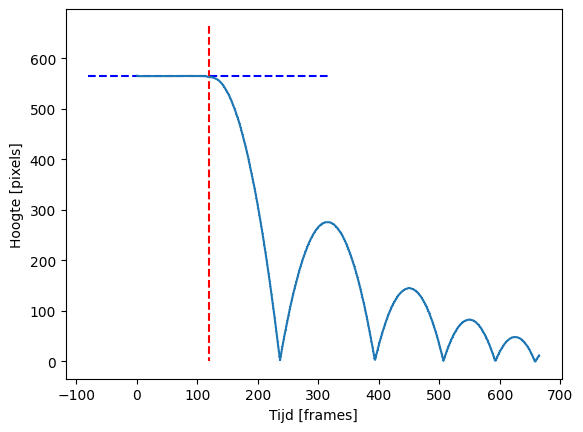

de eerste 120 frames worden afgeknipt.
de valhoogte coordinaat is 564.1300200000001.
Meting op dikte V_d0_1


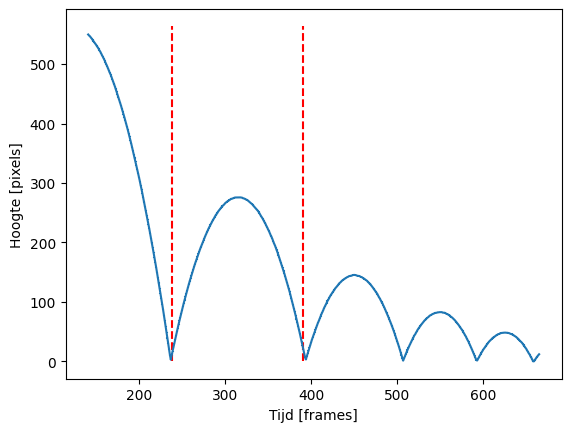

Meting op dikte V_d0_1


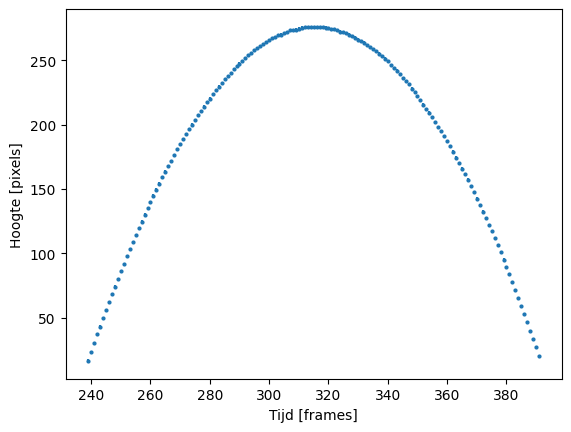

([565.532013, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.895019, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.728027, 564.895019, 564.728027, 564.728027, 564.728027, 564.728027, 564.895019, 564.895019, 564.728027, 564.728027, 564.895019, 564.728027, 564.728027, 564.895019, 564.895019, 564.728027, 564.728027, 564.728027, 564.895019, 564.728027, 564.728027, 564.895019, 565.061035, 565.061035, 565.061035, 564.895019, 565.061035, 565.061035, 565.061035, 56

In [ ]:
SPECIFIC_FOLDER = "metingen_0_40"
NETWORK_FOLDER = Path(rf"Z:\Data_Manou_Maria\{SPECIFIC_FOLDER}")

def databewerken(filename):


    # dont tweak these
    average_first_N_points = 0
    delete_first_elements = 0
    laagtepunt_1 = 0
    laagtepunt_2 = 0
    
    #data_current =  pd.read_csv(rf"metingen_3/{filename}.mqa", sep='\t')
    file_path = NETWORK_FOLDER / f"{filename}.mqa"
    data_current =  pd.read_csv(file_path, sep='\t')

    omgedraaid_y_current = data_current.iloc[:, 2] #Camera hangt scheef, dus omdraaien die handel en lezen van de x-coordinaten.
    frame_current = data_current.iloc[:, 0]
    laagste_y_current = max(omgedraaid_y_current)
    
    y_current = []
    for oy in omgedraaid_y_current:
        y = laagste_y_current - oy
        y_current.append(y)

    # ervoor zorgen dat eerste rechte data wordt afgeknipt
    for i in range(N_points):           # gemiddelde nemen van eerste N punten
        average_first_N_points += y_current[i]
    average_first_N_points = average_first_N_points / N_points


    while abs(y_current[delete_first_elements] - average_first_N_points) < leniency:        # wachten tot een punt te ver van het gemiddelde van de eerste N af zit
        delete_first_elements += 1
    delete_first_elements -= 10     # Voor de zekerheid een beetje doorspoelen



    afgeknipt_y_current = y_current[delete_first_elements + 20:]     # de rechte elementen afknippen
    afgeknipt_frame_current = frame_current[delete_first_elements + 20:]

    smoothknip = gaussian_filter1d(afgeknipt_y_current, sigma = sigma)     # hier een gaussisch filter overheen halen, zodat alle punten mooi zijn


    for i in range(len(smoothknip) - 1):
        if smoothknip[i] < smoothknip[i + 1] and smoothknip[i] < smoothknip[i-1]:      # van deze data de eerste twee minimums vinden en het frame hiervan onthouden
            print(f"laagtepunt bevindt zich op {i} frames.")
            if laagtepunt_1 == 0:
                laagtepunt_1 = i + 2
            else:
                laagtepunt_2 = i - 2
                break
    
    hoogste_y_current = (min(y_current[:delete_first_elements]) + max(y_current[:delete_first_elements]) ) / 2
    laagste_y_current = min(y_current)

    y = [0, hoogste_y_current]
    x1 = [laagtepunt_1 + delete_first_elements + 20, laagtepunt_1 + delete_first_elements + 20]
    x2 = [laagtepunt_2 + delete_first_elements + 20, laagtepunt_2 + delete_first_elements + 20]

    print((f'Meting op dikte {filename}'))
    #plt.title(f'Meting op dikte {filename}')
    plt.errorbar(frame_current, y_current, yerr = y_err)
    plt.plot([delete_first_elements -200, delete_first_elements + 200], [hoogste_y_current, hoogste_y_current], 'b--')
    plt.plot([delete_first_elements, delete_first_elements], [hoogste_y_current + 100, 0], 'r--')
    plt.xlabel('Tijd [frames]')
    plt.ylabel('Hoogte [pixels]')
    plt.show()
    print(f"de eerste {delete_first_elements} frames worden afgeknipt.")
    print(f'de valhoogte coordinaat is {hoogste_y_current}.')

    print((f'Meting op dikte {filename}'))
    #plt.title(f'Meting op dikte {filename}')
    plt.errorbar(afgeknipt_frame_current, afgeknipt_y_current, yerr = y_err)
    plt.xlabel('Tijd [frames]')
    plt.ylabel('Hoogte [pixels]')
    plt.plot(x1, y, 'r--')
    plt.plot(x2, y, 'r--')
    plt.show()

    print((f'Meting op dikte {filename}'))
    #plt.title(f'Meting op dikte {filename}')
    plt.errorbar(afgeknipt_frame_current[laagtepunt_1 : laagtepunt_2], afgeknipt_y_current[laagtepunt_1 : laagtepunt_2], yerr = y_err, markersize = 2, fmt = 'o')
    plt.xlabel('Tijd [frames]')
    plt.ylabel('Hoogte [pixels]')
    plt.show()

    return y_current, afgeknipt_y_current, frame_current, laagtepunt_1, laagtepunt_2, delete_first_elements

filename = f"V_d0_1"
print(databewerken(filename))